# Counterfeit Medicine Detection Using Machine Learning

**Reference Paper:** *Analyzing the Counterfeit Medicines Based on Classification Using Machine Learning Techniques*

## Pipeline
1. **YOLOv8** — Detect & crop medicine regions
2. **Feature Extraction** — Color (6) + Texture/GLCM (4) + Shape (3) = 13 features
3. **ML Classification** — Random Forest, SVM, XGBoost
4. **Comparison** — Accuracy, Precision, Recall, F1-Score
5. **Independent Testing** — `ind_test/` images

## 1. Setup & Imports

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from ultralytics import YOLO
from skimage.feature import graycomatrix, graycoprops

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import joblib

print('All imports successful.')

All imports successful.


## 2. Dataset Overview

In [2]:
base_path = '.'
splits = ['train', 'valid', 'test']

for split in splits:
    img_path = os.path.join(base_path, split, 'images')
    lbl_path = os.path.join(base_path, split, 'labels')
    num_images = len(os.listdir(img_path))
    num_labels = len(os.listdir(lbl_path))
    print(f'{split.upper()}: Images={num_images}, Labels={num_labels}')

print()
label_dir = 'train/labels'
counter = Counter()
for file in os.listdir(label_dir):
    with open(os.path.join(label_dir, file), 'r') as f:
        for line in f.readlines():
            class_id = line.split()[0]
            counter[class_id] += 1
print('Class distribution in TRAIN:', counter)

FileNotFoundError: [WinError 3] The system cannot find the path specified: '.\\train\\images'

## 3. YOLOv8 — Load Model & Generate Crops

We use the pre-trained YOLOv8 model to detect medicine regions and save crops.
The crops are saved to `runs/detect/predict/crops/authentic/` and `counterfeit/`.

In [ ]:
yolo_model = YOLO('runs/detect/train13/weights/best.pt')
print('YOLO model loaded.')

# Check if crops already exist
crops_path = 'runs/detect/predict/crops'
if os.path.exists(crops_path):
    for cls_name in os.listdir(crops_path):
        cls_path = os.path.join(crops_path, cls_name)
        if os.path.isdir(cls_path):
            print(f'  {cls_name}: {len(os.listdir(cls_path))} crops')
    print('Using existing crops.')
else:
    print('Generating crops... (this may take a while)')
    yolo_model.predict(
        source='train/images',
        save_crop=True,
        save=True,
        conf=0.25
    )
    print('Crops generated.')

YOLO model loaded.
  authentic: 7212 crops
  counterfeit: 1110 crops
Using existing crops.


## 4. Feature Extraction from YOLO Crops

Extract **13 features** from each YOLO-detected crop:
- **Color:** Mean & Std of R, G, B channels (6 features)
- **Texture:** GLCM contrast, energy, homogeneity, correlation (4 features)
- **Shape:** Contour area, perimeter, aspect ratio (3 features)

### 4.1 Color Features

In [3]:
base_path = 'runs/detect/predict/crops'

data = []

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)

        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Mean and Std for each channel
        mean = np.mean(img, axis=(0,1))
        std = np.std(img, axis=(0,1))

        features = [
            mean[0], mean[1], mean[2],   # R, G, B mean
            std[0], std[1], std[2],      # R, G, B std
        ]

        label = 0 if class_name == 'authentic' else 1
        data.append(features + [label])

columns = ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'label']
df = pd.DataFrame(data, columns=columns)

print(f'Color features extracted: {len(df)} samples')
df.head()

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'runs/detect/predict/crops'

### 4.2 Texture Features (GLCM)

In [4]:
texture_data = []

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)

        img = cv2.imread(img_path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize ONLY for GLCM stability
        gray = cv2.resize(gray, (256, 256))

        glcm = graycomatrix(gray, distances=[1], angles=[0],
                            levels=256, symmetric=True, normed=True)

        contrast    = graycoprops(glcm, 'contrast')[0, 0]
        energy      = graycoprops(glcm, 'energy')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]

        label = 0 if class_name == 'authentic' else 1
        texture_data.append([contrast, energy, homogeneity, correlation, label])

texture_columns = ['contrast', 'energy', 'homogeneity', 'correlation', 'label']
texture_df = pd.DataFrame(texture_data, columns=texture_columns)

print(f'Texture features extracted: {len(texture_df)} samples')
texture_df.head()

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'runs/detect/predict/crops'

### 4.3 Shape Features

In [5]:
shape_data = []

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)

        img = cv2.imread(img_path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Threshold to get object mask
        _, thresh = cv2.threshold(gray, 127, 255,
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) > 0:
            cnt = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = float(w) / h if h != 0 else 0
        else:
            area = 0
            perimeter = 0
            aspect_ratio = 0

        label = 0 if class_name == 'authentic' else 1
        shape_data.append([area, perimeter, aspect_ratio, label])

shape_columns = ['area', 'perimeter', 'aspect_ratio', 'label']
shape_df = pd.DataFrame(shape_data, columns=shape_columns)

print(f'Shape features extracted: {len(shape_df)} samples')
shape_df.head()

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'runs/detect/predict/crops'

### 4.4 Combine All Features

In [6]:
# Drop duplicate label columns from texture and shape
texture_df_no_label = texture_df.drop(columns=['label'])
shape_df_no_label = shape_df.drop(columns=['label'])

# Combine all features
final_df = pd.concat(
    [df.drop(columns=['label']),
     texture_df_no_label,
     shape_df_no_label,
     df['label']],
    axis=1
)

print('Total samples:', len(final_df))
print('Total features (including label):', final_df.shape[1])
print()
print('Class distribution:')
print(final_df['label'].value_counts().rename({0: 'authentic', 1: 'counterfeit'}))
print()
final_df.head()

NameError: name 'texture_df' is not defined

## 5. Data Preparation

- 80/20 train-test split with stratification
- StandardScaler normalization

In [7]:
# Separate features and label
X = final_df.drop(columns=['label'])
y = final_df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training samples:', X_train_scaled.shape)
print('Testing samples:', X_test_scaled.shape)

NameError: name 'final_df' is not defined

## 6. Model Training & Evaluation

### 6.1 Random Forest (RF)

**Gini Index** (Paper Eq. 1):  
Gini = 1 - [(B+)^2 + (B-)^2]

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print('=' * 60)
print('RANDOM FOREST — Results')
print('=' * 60)
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf,
                            target_names=['authentic', 'counterfeit']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

NameError: name 'X_train_scaled' is not defined

### 6.2 Support Vector Machine (SVM)

**SVM Decision Function** (Paper Eq. 3):  
h(p) = q + sum(y_t * b_t * K(p, p_t))

Using RBF kernel for nonlinear classification.

In [10]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print('=' * 60)
print('SVM (RBF Kernel) — Results')
print('=' * 60)
print('Accuracy:', accuracy_score(y_test, y_pred_svm))
print()
print(classification_report(y_test, y_pred_svm,
                            target_names=['authentic', 'counterfeit']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_svm))

SVM (RBF Kernel) — Results
Accuracy: 0.9201201201201201

              precision    recall  f1-score   support

   authentic       0.99      0.92      0.95      1443
 counterfeit       0.64      0.94      0.76       222

    accuracy                           0.92      1665
   macro avg       0.81      0.93      0.86      1665
weighted avg       0.94      0.92      0.93      1665

Confusion Matrix:
[[1323  120]
 [  13  209]]


### 6.3 XGBoost Classifier

In [11]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=6,  # imbalance handling
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print('=' * 60)
print('XGBoost — Results')
print('=' * 60)
print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print()
print(classification_report(y_test, y_pred_xgb,
                            target_names=['authentic', 'counterfeit']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost — Results
Accuracy: 0.9621621621621622

              precision    recall  f1-score   support

   authentic       0.98      0.98      0.98      1443
 counterfeit       0.87      0.84      0.86       222

    accuracy                           0.96      1665
   macro avg       0.92      0.91      0.92      1665
weighted avg       0.96      0.96      0.96      1665

Confusion Matrix:
[[1415   28]
 [  35  187]]


## 7. Model Comparison

Comparing all classifiers (matching Paper Table 2 and Graph 1).

In [12]:
models = {
    'Random Forest': y_pred_rf,
    'SVM (RBF)':     y_pred_svm,
    'XGBoost':       y_pred_xgb
}

results = {}
for name, y_pred in models.items():
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

comparison_df = pd.DataFrame(results).T
comparison_df.index.name = 'Algorithm'

print('=' * 70)
print('          COMPARATIVE RESULTS — ALL MODELS')
print('=' * 70)
print(comparison_df.round(4).to_string())
print()
comparison_df.style.format('{:.2%}').set_caption('Model Performance Comparison').background_gradient(cmap='Greens', axis=0)

          COMPARATIVE RESULTS — ALL MODELS
               Accuracy  Precision  Recall  F1-Score
Algorithm                                           
Random Forest    0.9405     0.9406  0.9405    0.9345
SVM (RBF)        0.9201     0.9429  0.9201    0.9263
XGBoost          0.9622     0.9617  0.9622    0.9619



,Accuracy,Precision,Recall,F1-Score
Algorithm,,,,
Random Forest,94.05%,94.06%,94.05%,93.45%
SVM (RBF),92.01%,94.29%,92.01%,92.63%
XGBoost,96.22%,96.17%,96.22%,96.19%


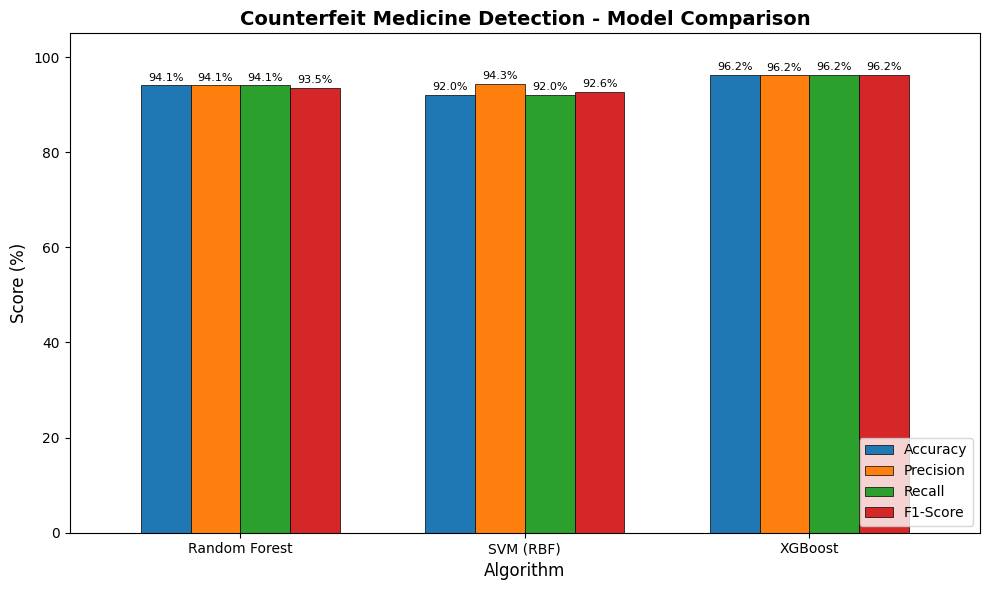

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

comparison_pct = comparison_df * 100
comparison_pct.plot(kind='bar', ax=ax, width=0.7, edgecolor='black', linewidth=0.5)

ax.set_title('Counterfeit Medicine Detection - Model Comparison',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_xlabel('Algorithm', fontsize=12)
ax.set_ylim(0, 105)
ax.legend(loc='lower right', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrices

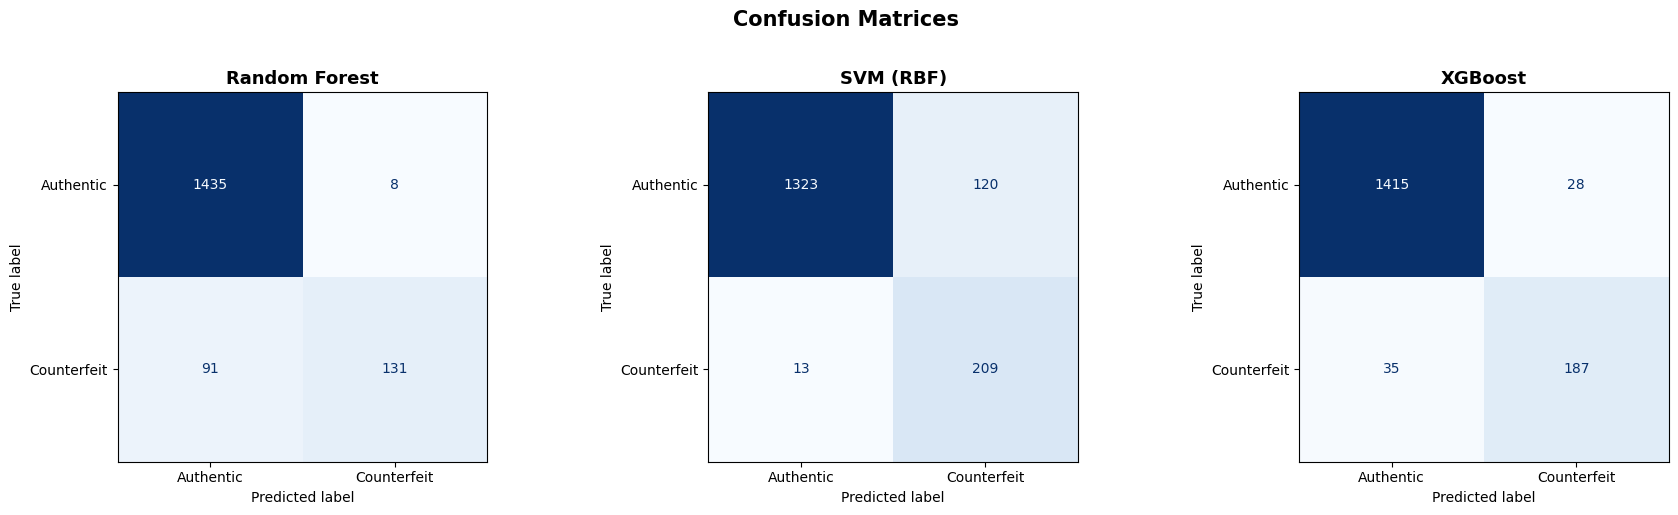

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Authentic', 'Counterfeit'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance (Random Forest)

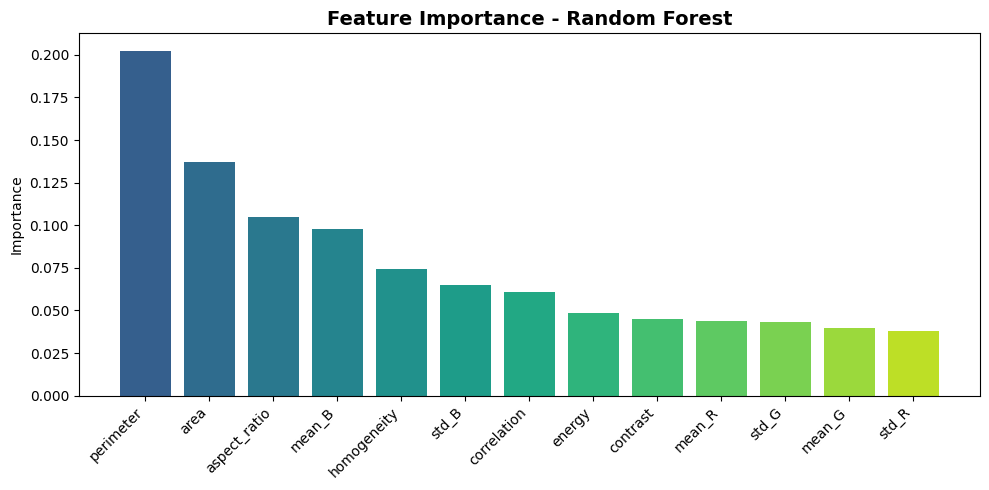

In [15]:
feature_names = [
    'mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B',
    'contrast', 'energy', 'homogeneity', 'correlation',
    'area', 'perimeter', 'aspect_ratio'
]

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_names)))
ax.bar(range(len(feature_names)), importances[indices], color=colors)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
ax.set_title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Trained Models

In [16]:
joblib.dump(rf_model,  'rf_model.pkl')
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(scaler,    'scaler.pkl')

print('Models saved:')
print('  - rf_model.pkl')
print('  - svm_model.pkl')
print('  - xgb_model.pkl')
print('  - scaler.pkl')

Models saved:
  - rf_model.pkl
  - svm_model.pkl
  - xgb_model.pkl
  - scaler.pkl


## 10. Single-Image Inference Pipeline

**Exactly matching the original working inference code:**  
Image -> YOLO detection -> Crop first box -> Extract 13 features -> Scale -> XGBoost predict (threshold=0.30)

In [17]:
# Feature extraction function — EXACT match to original working code
def extract_features(img):
    # ----- COLOR FEATURES -----
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mean = np.mean(img_rgb, axis=(0,1))
    std = np.std(img_rgb, axis=(0,1))

    # ----- TEXTURE FEATURES -----
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (256, 256))

    glcm = graycomatrix(gray,
                        distances=[1],
                        angles=[0],
                        levels=256,
                        symmetric=True,
                        normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    # ----- SHAPE FEATURES -----
    _, thresh = cv2.threshold(gray, 127, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        cnt = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h if h != 0 else 0
    else:
        area = 0
        perimeter = 0
        aspect_ratio = 0

    features = [
        mean[0], mean[1], mean[2],
        std[0], std[1], std[2],
        contrast, energy, homogeneity, correlation,
        area, perimeter, aspect_ratio
    ]

    return np.array(features).reshape(1, -1)


# Predict function — EXACT match to original working code
def predict_image(image_path, model=None, model_name='XGBoost', threshold=0.30):
    if model is None:
        model = xgb_model

    # Step 1: YOLO detection
    results = yolo_model(image_path, verbose=False)

    if len(results[0].boxes) == 0:
        print('No medicine detected.')
        return None

    # Take first detected box
    box = results[0].boxes.xyxy[0].cpu().numpy().astype(int)

    img = cv2.imread(image_path)
    crop = img[box[1]:box[3], box[0]:box[2]]

    # Step 2: Extract features
    features = extract_features(crop)

    # Step 3: Scale features
    feat_names = [
        'mean_R', 'mean_G', 'mean_B',
        'std_R', 'std_G', 'std_B',
        'contrast', 'energy', 'homogeneity', 'correlation',
        'area', 'perimeter', 'aspect_ratio'
    ]

    features_df = pd.DataFrame(features, columns=feat_names)
    features_scaled = scaler.transform(features_df)

    # Step 4: Predict
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(features_scaled)[0]
        prediction = 1 if prob[1] > threshold else 0
        confidence = prob[prediction]
    else:
        prediction = model.predict(features_scaled)[0]
        confidence = None

    label = 'AUTHENTIC' if prediction == 0 else 'COUNTERFEIT'

    if confidence is not None:
        print(f'[{model_name}] Prediction: {label}  (confidence: {confidence:.4f})')
    else:
        print(f'[{model_name}] Prediction: {label}')

    return prediction

print('Inference functions defined.')

Inference functions defined.


## 11. Independent Testing (ind_test/)

Test all 3 models on the 10 test images.

In [18]:
# Ground truth
ind_test_gt = {}
for i in range(1, 6):
    ind_test_gt[f'fake{i}.jpg'] = {'label': 1, 'expected': 'COUNTERFEIT'}
    ind_test_gt[f'org{i}.jpg']  = {'label': 0, 'expected': 'AUTHENTIC'}

ind_test_dir = 'ind_test'
all_results = []

# Models to test with their thresholds
test_models = [
    ('Random Forest', rf_model,  0.30),
    ('SVM',           svm_model, 0.30),
    ('XGBoost',       xgb_model, 0.30),
]

print('=' * 80)
print('INDEPENDENT TESTING — ind_test/')
print('=' * 80)

for img_file in sorted(ind_test_gt.keys()):
    img_path = os.path.join(ind_test_dir, img_file)
    gt = ind_test_gt[img_file]

    print(f'\n--- {img_file} (expected: {gt["expected"]}) ---')

    row = {'Image': img_file, 'Expected': gt['expected']}

    for model_name, model_obj, thresh in test_models:
        pred = predict_image(img_path, model=model_obj,
                            model_name=model_name, threshold=thresh)
        if pred is not None:
            pred_label = 'AUTHENTIC' if pred == 0 else 'COUNTERFEIT'
            correct = 'OK' if pred == gt['label'] else 'WRONG'
        else:
            pred_label = 'NO_DETECT'
            correct = 'WRONG'
        row[model_name] = pred_label
        row[f'{model_name}_correct'] = correct

    all_results.append(row)

INDEPENDENT TESTING — ind_test/

--- fake1.jpg (expected: COUNTERFEIT) ---
[Random Forest] Prediction: AUTHENTIC  (confidence: 0.9150)
[SVM] Prediction: COUNTERFEIT  (confidence: 0.5450)
[XGBoost] Prediction: AUTHENTIC  (confidence: 0.9970)

--- fake2.jpg (expected: COUNTERFEIT) ---
[Random Forest] Prediction: AUTHENTIC  (confidence: 0.8500)
[SVM] Prediction: COUNTERFEIT  (confidence: 0.6621)
[XGBoost] Prediction: AUTHENTIC  (confidence: 0.7590)

--- fake3.jpg (expected: COUNTERFEIT) ---
[Random Forest] Prediction: COUNTERFEIT  (confidence: 0.6750)
[SVM] Prediction: COUNTERFEIT  (confidence: 0.6453)
[XGBoost] Prediction: COUNTERFEIT  (confidence: 0.9281)

--- fake4.jpg (expected: COUNTERFEIT) ---
[Random Forest] Prediction: COUNTERFEIT  (confidence: 0.3150)
[SVM] Prediction: AUTHENTIC  (confidence: 0.8879)
[XGBoost] Prediction: COUNTERFEIT  (confidence: 0.7676)

--- fake5.jpg (expected: COUNTERFEIT) ---
[Random Forest] Prediction: AUTHENTIC  (confidence: 0.8700)
[SVM] Prediction: AUTHE

In [19]:
results_df = pd.DataFrame(all_results)

display_cols = ['Image', 'Expected', 'Random Forest', 'SVM', 'XGBoost']
print('\n' + '=' * 80)
print('PREDICTION RESULTS — ind_test/')
print('=' * 80)
print(results_df[display_cols].to_string(index=False))

print('\n' + '=' * 80)
print('ACCURACY on ind_test (10 images)')
print('=' * 80)
for model_name in ['Random Forest', 'SVM', 'XGBoost']:
    col = f'{model_name}_correct'
    n_correct = sum(results_df[col] == 'OK')
    total = len(results_df)
    print(f'  {model_name:>15}: {n_correct}/{total} correct ({n_correct/total*100:.0f}%)')


PREDICTION RESULTS — ind_test/
    Image    Expected Random Forest         SVM     XGBoost
fake1.jpg COUNTERFEIT     AUTHENTIC COUNTERFEIT   AUTHENTIC
fake2.jpg COUNTERFEIT     AUTHENTIC COUNTERFEIT   AUTHENTIC
fake3.jpg COUNTERFEIT   COUNTERFEIT COUNTERFEIT COUNTERFEIT
fake4.jpg COUNTERFEIT   COUNTERFEIT   AUTHENTIC COUNTERFEIT
fake5.jpg COUNTERFEIT     AUTHENTIC   AUTHENTIC   AUTHENTIC
 org1.jpg   AUTHENTIC     AUTHENTIC   AUTHENTIC   AUTHENTIC
 org2.jpg   AUTHENTIC     AUTHENTIC   AUTHENTIC   AUTHENTIC
 org3.jpg   AUTHENTIC     AUTHENTIC   AUTHENTIC   AUTHENTIC
 org4.jpg   AUTHENTIC     AUTHENTIC   AUTHENTIC   AUTHENTIC
 org5.jpg   AUTHENTIC     AUTHENTIC   AUTHENTIC   AUTHENTIC

ACCURACY on ind_test (10 images)
    Random Forest: 7/10 correct (70%)
              SVM: 8/10 correct (80%)
          XGBoost: 7/10 correct (70%)


### Visual Results

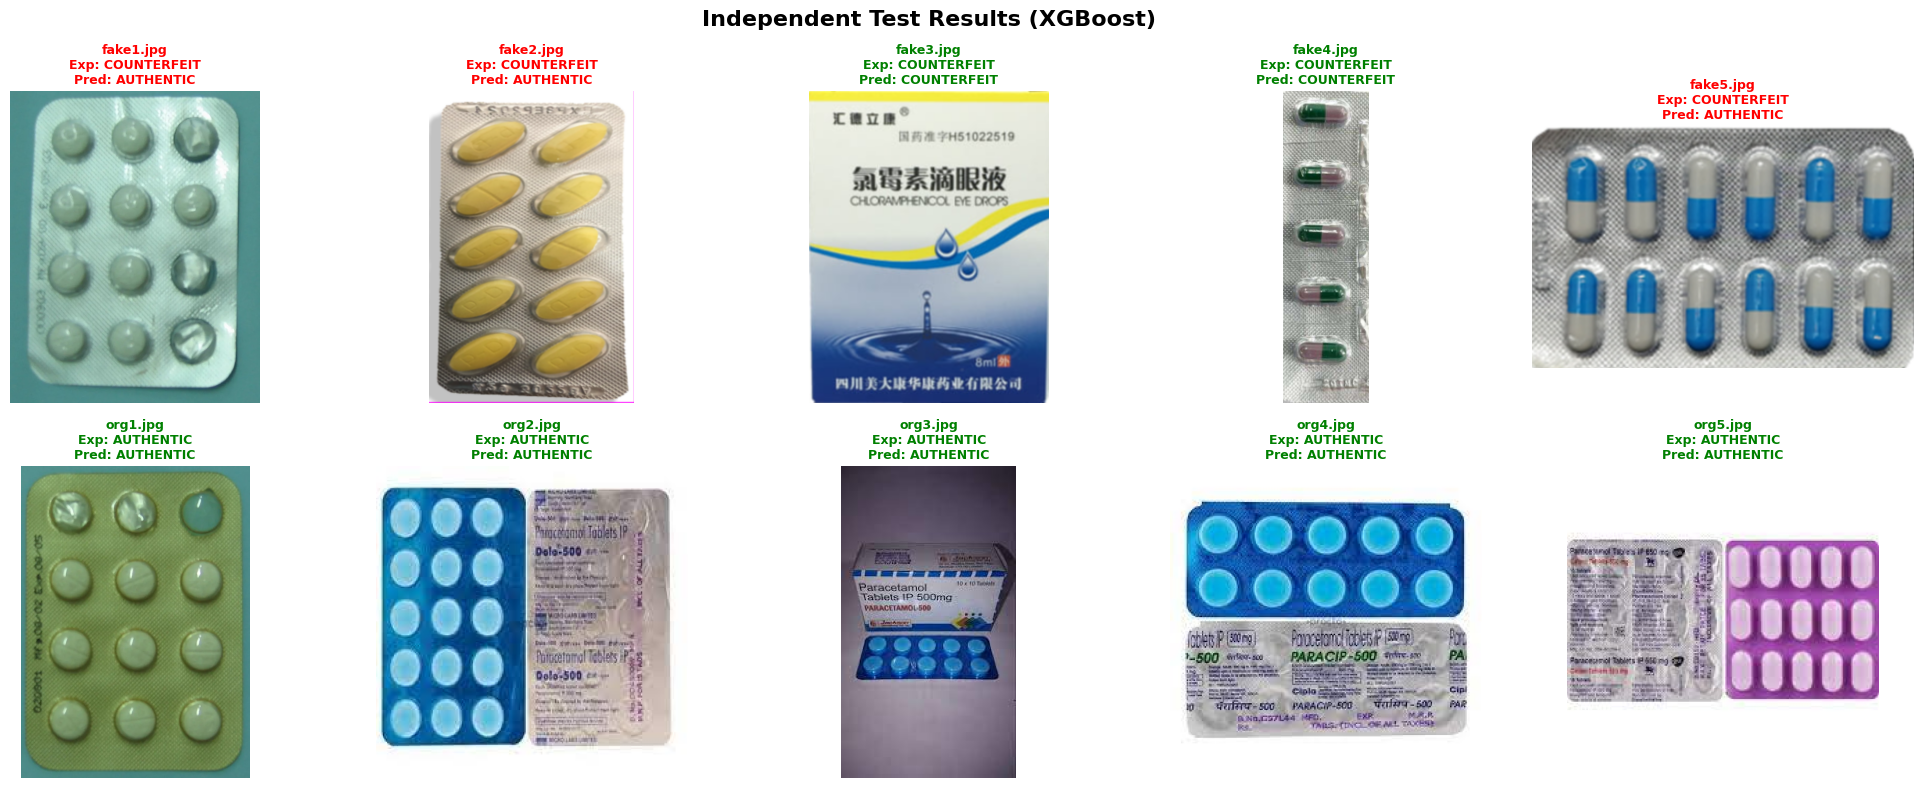

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, img_file in enumerate(sorted(ind_test_gt.keys())):
    row_idx = idx // 5
    col_idx = idx % 5
    ax = axes[row_idx, col_idx]

    img_path = os.path.join(ind_test_dir, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    gt = ind_test_gt[img_file]
    res_row = [r for r in all_results if r['Image'] == img_file]
    if res_row:
        xgb_pred = res_row[0].get('XGBoost', '?')
        correct = res_row[0].get('XGBoost_correct', 'WRONG')
        color = 'green' if correct == 'OK' else 'red'
        ax.set_title(f'{img_file}\nExp: {gt["expected"]}\nPred: {xgb_pred}',
                     fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Independent Test Results (XGBoost)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ind_test_results.png', dpi=150, bbox_inches='tight')
plt.show()